# HVFHV Model 1 + Model 2

- Model 1 is a cross-zone descriptive association: higher `DS_z` versus 2025 vs 2024 percent volume change.
- Model 2 is an exposure-gradient DiD-style panel estimate using the pre-policy 2024 geography-based exposure, `charged_share_2024_geo`.
- The outcome is `log_n_trips`, `post` is the 2025 indicator, and the key interaction is `post:charged_share_2024_geo`.
- Coefficients are estimated under assumptions and should be read as associations, not causal proof.

## Inputs

Model 2 exposure is the pre-policy **2024 geography-based** CRZ share, `charged_share_2024_geo`, measured before the 2025 policy so the treatment does not use post-policy observed charge status. The 2025 observed `charged_cbd_flag` enters only as a validation diagnostic.

In [1]:
from pathlib import Path
import os
import tempfile

import numpy as np
import pandas as pd

try:
    import statsmodels.formula.api as smf
    STATSMODELS_AVAILABLE = True
except ImportError:
    smf = None
    STATSMODELS_AVAILABLE = False

MPLCONFIGDIR = Path(tempfile.gettempdir()) / "matplotlib-cache"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPLCONFIGDIR)

try:
    import matplotlib
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    plt = None
    MATPLOTLIB_AVAILABLE = False

if MATPLOTLIB_AVAILABLE:
    plt.rcParams.update({"figure.dpi": 120})

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "data" / "processed").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent

MODELING = REPO_ROOT / "data" / "processed" / "modeling"
DS = REPO_ROOT / "data" / "processed" / "disruption_score"
RESULTS_TABLES = REPO_ROOT / 'results' / 'modeling' / 'tables'
RESULTS_FIGURES = REPO_ROOT / 'results' / 'modeling' / 'figures'
RESULTS_TABLES.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

PATHS = {
    "model1_features": MODELING / "hvfhv_model1_zone_features.csv",
    "monthly_panel": DS / "hvfhv_monthly_panel.csv",
    "exposure_validation": DS / "hvfhv_model2_exposure_validation.csv",
    "pretrend_2024_diagnostic": DS / "hvfhv_pretrend_2024_diagnostic.csv",
    "placebo_2023_2024_results": DS / "hvfhv_placebo_2023_2024_results.csv",
    "pretrend_placebo_notes": DS / "hvfhv_pretrend_placebo_notes.md",
}

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)


def read_required_csv(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing required input: {path.relative_to(REPO_ROOT)}")
    return pd.read_csv(path)


def pct_value(x):
    return 100.0 * x


def corr_ci(frame, x_col, y_col, method="pearson"):
    data = frame[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if method == "spearman":
        x = data[x_col].rank(method="average").to_numpy(float)
        y = data[y_col].rank(method="average").to_numpy(float)
    else:
        x = data[x_col].to_numpy(float)
        y = data[y_col].to_numpy(float)
    n = len(data)
    if n < 3:
        return {"method": method, "n": n, "corr": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    corr = float(np.corrcoef(x, y)[0, 1])
    if n > 3 and abs(corr) < 1:
        z_value = np.arctanh(corr)
        se = 1 / np.sqrt(n - 3)
        ci_low, ci_high = np.tanh([z_value - 1.96 * se, z_value + 1.96 * se])
    else:
        ci_low, ci_high = np.nan, np.nan
    return {"method": method, "n": n, "corr": corr, "ci_low": float(ci_low), "ci_high": float(ci_high)}


def unique_keep_order(items):
    output = []
    for item in items:
        if item not in output:
            output.append(item)
    return output


def build_design_matrix(frame, numeric_terms, categorical_terms=None, interaction_terms=None):
    categorical_terms = categorical_terms or []
    interaction_terms = interaction_terms or []
    matrices = [np.ones((len(frame), 1))]
    names = ["Intercept"]
    for col in numeric_terms:
        matrices.append(frame[[col]].to_numpy(float))
        names.append(col)
    for left, right, name in interaction_terms:
        values = frame[left].to_numpy(float) * frame[right].to_numpy(float)
        matrices.append(values.reshape(-1, 1))
        names.append(name)
    for col in categorical_terms:
        categories = sorted(pd.Series(frame[col]).dropna().unique().tolist())
        for category in categories[1:]:
            matrices.append((frame[col].to_numpy() == category).astype(float).reshape(-1, 1))
            names.append(f"C({col})[{category}]")
    return np.hstack(matrices), names


def fit_ols_design(frame, y_col, numeric_terms, categorical_terms=None, interaction_terms=None, term="DS_z", weights_col=None, cluster_col=None):
    categorical_terms = categorical_terms or []
    interaction_terms = interaction_terms or []
    needed = [y_col] + list(numeric_terms) + list(categorical_terms)
    for left, right, name in interaction_terms:
        needed.extend([left, right])
    if weights_col is not None:
        needed.append(weights_col)
    if cluster_col is not None:
        needed.append(cluster_col)
    if "zone" in frame.columns:
        needed.append("zone")
    if "direction" in frame.columns:
        needed.append("direction")

    data = frame[unique_keep_order(needed)].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if weights_col is not None:
        data = data[data[weights_col] > 0].copy()

    X, names = build_design_matrix(data, numeric_terms, categorical_terms, interaction_terms)
    y = data[y_col].to_numpy(float)
    weights = np.ones(len(data)) if weights_col is None else data[weights_col].to_numpy(float)
    sqrt_weights = np.sqrt(weights)
    X_weighted = X * sqrt_weights[:, None]
    y_weighted = y * sqrt_weights

    xtx_inv = np.linalg.pinv(X_weighted.T @ X_weighted)
    beta = xtx_inv @ (X_weighted.T @ y_weighted)
    residual = y - X @ beta
    n_obs = len(data)
    rank = int(np.linalg.matrix_rank(X_weighted))

    if cluster_col is not None:
        groups = data[cluster_col].to_numpy()
        unique_groups = pd.unique(groups)
        meat = np.zeros((X.shape[1], X.shape[1]))
        for group in unique_groups:
            mask = groups == group
            score = X[mask].T @ (weights[mask] * residual[mask])
            meat += np.outer(score, score)
        group_count = len(unique_groups)
        correction = (group_count / (group_count - 1)) * ((n_obs - 1) / (n_obs - rank)) if group_count > 1 and n_obs > rank else 1.0
        covariance = correction * xtx_inv @ meat @ xtx_inv
        se_type = f"cluster_{cluster_col}"
    else:
        sigma2 = float((weights * residual ** 2).sum() / max(n_obs - rank, 1))
        covariance = sigma2 * xtx_inv
        se_type = "conventional"

    std_errors = np.sqrt(np.maximum(np.diag(covariance), 0))
    if term not in names:
        raise ValueError(f"Term not found in design matrix: {term}")
    term_index = names.index(term)
    coef = float(beta[term_index])
    se = float(std_errors[term_index])
    ci_low = coef - 1.96 * se
    ci_high = coef + 1.96 * se
    units = data[["zone", "direction"]].drop_duplicates().shape[0] if {"zone", "direction"}.issubset(data.columns) else np.nan
    return {
        "coef": coef,
        "std_error": se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "n": int(n_obs),
        "rank": rank,
        "zone_direction_units": units,
        "se_type": se_type,
        "engine": "fallback_ols",
    }


def fit_model2_spec(frame, model_name, fe=False, weights_col=None, exposure="charged_share_2024_geo"):
    term = f"post:{exposure}"
    needed = ["log_n_trips", "post", exposure, "zone", "direction", "month"]
    if fe:
        needed.append("zone_direction")
    if weights_col is not None:
        needed.append(weights_col)
    data = frame[unique_keep_order(needed)].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if weights_col is not None:
        data = data[data[weights_col] > 0].copy()

    formula = f"log_n_trips ~ post * {exposure}"
    if fe:
        formula = f"log_n_trips ~ post + post:{exposure} + C(zone_direction) + C(month)"

    if STATSMODELS_AVAILABLE:
        if weights_col is None:
            fitted = smf.ols(formula, data=data).fit(cov_type="cluster", cov_kwds={"groups": data["zone"]})
        else:
            fitted = smf.wls(formula, data=data, weights=data[weights_col]).fit(cov_type="cluster", cov_kwds={"groups": data["zone"]})
        coef = float(fitted.params[term])
        se = float(fitted.bse[term])
        ci_low, ci_high = [float(v) for v in fitted.conf_int().loc[term]]
        result = {
            "model": model_name,
            "formula": formula,
            "coef": coef,
            "std_error": se,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "n": int(fitted.nobs),
            "rank": int(getattr(fitted, "df_model", np.nan) + 1) if np.isfinite(getattr(fitted, "df_model", np.nan)) else np.nan,
            "zone_direction_units": int(data[["zone", "direction"]].drop_duplicates().shape[0]),
            "se_type": "cluster_zone",
            "engine": "statsmodels",
        }
    else:
        categorical_terms = ["zone_direction", "month"] if fe else []
        numeric_terms = ["post", exposure] if not fe else ["post"]
        result = fit_ols_design(
            data,
            y_col="log_n_trips",
            numeric_terms=numeric_terms,
            categorical_terms=categorical_terms,
            interaction_terms=[("post", exposure, term)],
            term=term,
            weights_col=weights_col,
            cluster_col="zone",
        )
        result["model"] = model_name
        result["formula"] = formula

    result["pct_change"] = (np.exp(result["coef"]) - 1) * 100
    result["pct_ci_low"] = (np.exp(result["ci_low"]) - 1) * 100
    result["pct_ci_high"] = (np.exp(result["ci_high"]) - 1) * 100
    return result


def print_table(frame, columns=None, round_digits=3, index=False, max_rows=None):
    output = frame.copy()
    if columns is not None:
        output = output[columns]
    if max_rows is not None:
        output = output.head(max_rows)
    numeric_cols = output.select_dtypes(include=[np.number]).columns
    output[numeric_cols] = output[numeric_cols].round(round_digits)
    print(output.to_string(index=index))


print("Project root detected.")
print(f"statsmodels_available: {STATSMODELS_AVAILABLE}")
print(f"matplotlib_available: {MATPLOTLIB_AVAILABLE}")

Project root detected.
statsmodels_available: True
matplotlib_available: True


In [2]:
features = read_required_csv(PATHS["model1_features"])
monthly_panel = read_required_csv(PATHS["monthly_panel"])
exposure_validation = read_required_csv(PATHS["exposure_validation"])
pretrend_2024_diagnostic = read_required_csv(PATHS["pretrend_2024_diagnostic"])
placebo_2023_2024_results = read_required_csv(PATHS["placebo_2023_2024_results"])
pretrend_placebo_notes = PATHS["pretrend_placebo_notes"].read_text(encoding="utf-8")

required_columns = {
    "model1_features": [
        "location_id", "direction", "Borough", "zone_name", "service_zone", "DS_z", "DS_z_median",
        "pct_volume_change", "delta_volume", "n_trips_2024", "n_trips_2025", "low_n_flag",
        "avg_base_fare_2024", "avg_total_cost_2024", "avg_trip_distance_2024", "avg_trip_duration_2024",
        "log_n_trips_2024", "burden_rank", "DS_z_quartile",
    ],
    "monthly_panel": [
        "zone", "direction", "year", "month", "n_trips", "log_n_trips", "post", "Borough",
        "zone_name", "service_zone", "crz_zone", "charged_share_2024_geo",
    ],
    "exposure_validation": [
        "validation_level", "month", "n_trips_2025", "observed_charged_trips", "geography_exposed_trips",
        "match_rate", "share_observed_charged_missed_by_geo", "geography_precision", "geography_recall",
    ],
}

for name, columns in required_columns.items():
    frame = {"model1_features": features, "monthly_panel": monthly_panel, "exposure_validation": exposure_validation}[name]
    missing = sorted(set(columns) - set(frame.columns))
    if missing:
        raise ValueError(f"Missing columns in {name}: {missing}")

print("Allowed input files used:")
for name, path in PATHS.items():
    print(f"- {name}: {path.relative_to(REPO_ROOT)}")

print("\nInput shapes:")
for name, frame in [
    ("model1_features", features),
    ("monthly_panel", monthly_panel),
    ("exposure_validation", exposure_validation),
    ("pretrend_2024_diagnostic", pretrend_2024_diagnostic),
    ("placebo_2023_2024_results", placebo_2023_2024_results),
]:
    print(f"- {name}: {frame.shape[0]:,} rows x {frame.shape[1]:,} columns")
print(f"- pretrend_placebo_notes: loaded {len(pretrend_placebo_notes.splitlines()):,} text lines")

Allowed input files used:
- model1_features: data/processed/modeling/hvfhv_model1_zone_features.csv
- monthly_panel: data/processed/disruption_score/hvfhv_monthly_panel.csv
- exposure_validation: data/processed/disruption_score/hvfhv_model2_exposure_validation.csv
- pretrend_2024_diagnostic: data/processed/disruption_score/hvfhv_pretrend_2024_diagnostic.csv
- placebo_2023_2024_results: data/processed/disruption_score/hvfhv_placebo_2023_2024_results.csv
- pretrend_placebo_notes: data/processed/disruption_score/hvfhv_pretrend_placebo_notes.md

Input shapes:
- model1_features: 525 rows x 19 columns
- monthly_panel: 5,236 rows x 12 columns
- exposure_validation: 6 rows x 17 columns
- pretrend_2024_diagnostic: 16 rows x 6 columns
- placebo_2023_2024_results: 3 rows x 7 columns
- pretrend_placebo_notes: loaded 58 text lines


## Model 1 — `DS_z` ↔ volume change (cross-zone)

Model 1 asks whether zone-direction pairs with higher HVFHV fee burden had larger 2025-vs-2024 volume changes. It is a cross-sectional descriptive check on the `DS_z` burden metric — useful for a first look at whether higher burden lines up with volume, but not a clean causal design.

In [3]:
model1 = features[(~features["low_n_flag"].astype(bool)) & features["pct_volume_change"].notna()].copy()

corr_summary = pd.DataFrame([
    {"metric": "DS_z vs pct_volume_change", **corr_ci(model1, "DS_z", "pct_volume_change", "pearson")},
    {"metric": "DS_z vs pct_volume_change", **corr_ci(model1, "DS_z", "pct_volume_change", "spearman")},
    {"metric": "DS_z_median vs pct_volume_change", **corr_ci(model1, "DS_z_median", "pct_volume_change", "pearson")},
    {"metric": "DS_z_median vs pct_volume_change", **corr_ci(model1, "DS_z_median", "pct_volume_change", "spearman")},
])

print(f"Model 1 usable rows: {len(model1):,} of {len(features):,}")
print_table(corr_summary, ["metric", "method", "n", "corr", "ci_low", "ci_high"], round_digits=3)

Model 1 usable rows: 519 of 525
                          metric   method   n   corr  ci_low  ci_high
       DS_z vs pct_volume_change  pearson 519 -0.610  -0.661   -0.553
       DS_z vs pct_volume_change spearman 519 -0.643  -0.691   -0.589
DS_z_median vs pct_volume_change  pearson 519 -0.599  -0.652   -0.541
DS_z_median vs pct_volume_change spearman 519 -0.637  -0.686   -0.583


        DS_z_bin  n  avg_DS_z_pct  avg_volume_change_pct
(0.0092, 0.0185] 65          1.53                   4.32
(0.0185, 0.0224] 65          2.04                   4.92
(0.0224, 0.0254] 65          2.41                   4.78
(0.0254, 0.0299] 65          2.77                   2.83
(0.0299, 0.0347] 64          3.24                   2.27
 (0.0347, 0.042] 65          3.83                  -0.21
 (0.042, 0.0516] 65          4.65                  -2.89
(0.0516, 0.0638] 65          5.68                  -7.14


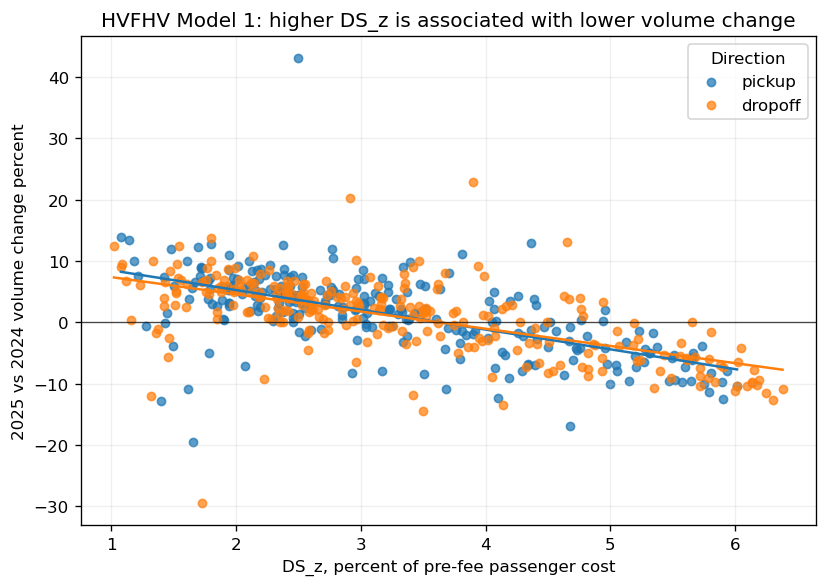

In [4]:
if MATPLOTLIB_AVAILABLE:
    fig, ax = plt.subplots(figsize=(7, 5))
    for direction, color in [("pickup", "tab:blue"), ("dropoff", "tab:orange")]:
        group = model1[model1["direction"].eq(direction)]
        ax.scatter(pct_value(group["DS_z"]), pct_value(group["pct_volume_change"]), alpha=0.72, s=24, label=direction, color=color)
        if len(group) >= 2:
            x = pct_value(group["DS_z"].to_numpy())
            y = pct_value(group["pct_volume_change"].to_numpy())
            slope, intercept = np.polyfit(x, y, 1)
            x_grid = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_grid, intercept + slope * x_grid, color=color, linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.7)
    ax.set_title("HVFHV Model 1: higher DS_z is associated with lower volume change")
    ax.set_xlabel("DS_z, percent of pre-fee passenger cost")
    ax.set_ylabel("2025 vs 2024 volume change percent")
    ax.legend(title="Direction")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    fig.savefig(RESULTS_FIGURES/'hvfhv_model1_dsz_vs_volume.png', dpi=180, bbox_inches='tight')
else:
    print("matplotlib_available is False, showing a compact binned table instead of a scatter plot.")

bin_summary = model1.assign(DS_z_bin=pd.qcut(model1["DS_z"], 8, duplicates="drop")).groupby("DS_z_bin", observed=True).agg(
    n=("location_id", "count"),
    avg_DS_z_pct=("DS_z", lambda s: pct_value(s.mean())),
    avg_volume_change_pct=("pct_volume_change", lambda s: pct_value(s.mean())),
).reset_index()
bin_summary["DS_z_bin"] = bin_summary["DS_z_bin"].astype(str)
print_table(bin_summary, round_digits=2, index=False)

In [5]:
quartile_all = model1.groupby("DS_z_quartile", observed=True).agg(
    n_pairs=("location_id", "count"),
    avg_DS_z_pct=("DS_z", lambda s: pct_value(s.mean())),
    avg_volume_change_pct=("pct_volume_change", lambda s: pct_value(s.mean())),
    median_volume_change_pct=("pct_volume_change", lambda s: pct_value(s.median())),
).reset_index()

quartile_by_direction = model1.groupby(["direction", "DS_z_quartile"], observed=True).agg(
    n_pairs=("location_id", "count"),
    avg_DS_z_pct=("DS_z", lambda s: pct_value(s.mean())),
    avg_volume_change_pct=("pct_volume_change", lambda s: pct_value(s.mean())),
    median_volume_change_pct=("pct_volume_change", lambda s: pct_value(s.median())),
).reset_index()

top_burden = (
    features.sort_values(["direction", "burden_rank"])
    .groupby("direction", group_keys=False)
    .head(8)
    [["burden_rank", "location_id", "direction", "Borough", "zone_name", "DS_z", "pct_volume_change", "n_trips_2024", "n_trips_2025"]]
    .rename(columns={"DS_z": "DS_z_pct", "pct_volume_change": "volume_change_pct"})
)
top_burden["DS_z_pct"] = pct_value(top_burden["DS_z_pct"])
top_burden["volume_change_pct"] = pct_value(top_burden["volume_change_pct"])

print("Quartile breakdown, all zone-direction pairs:")
print_table(quartile_all, round_digits=2)
print("\nQuartile breakdown by direction:")
print_table(quartile_by_direction, round_digits=2)
print("\nTop burden zones by direction:")
print_table(top_burden, round_digits=2)

Quartile breakdown, all zone-direction pairs:
DS_z_quartile  n_pairs  avg_DS_z_pct  avg_volume_change_pct  median_volume_change_pct
    Q1 lowest      130          1.79                   4.53                      5.67
           Q2      130          2.59                   3.89                      3.85
           Q3      128          3.53                   1.14                      1.52
   Q4 highest      131          5.15                  -5.08                     -5.79

Quartile breakdown by direction:
direction DS_z_quartile  n_pairs  avg_DS_z_pct  avg_volume_change_pct  median_volume_change_pct
  dropoff     Q1 lowest       65          1.76                   4.41                      5.59
  dropoff            Q2       66          2.64                   3.18                      3.55
  dropoff            Q3       64          3.61                   1.08                      1.63
  dropoff    Q4 highest       65          5.32                  -5.34                     -6.15
   pickup 

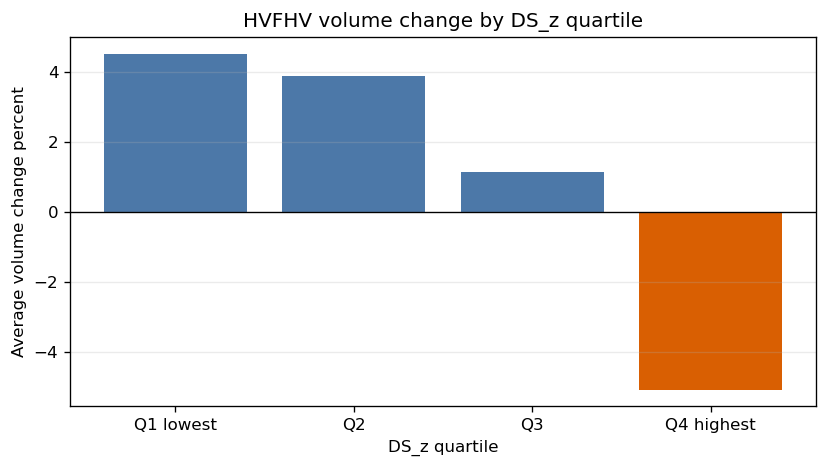

In [6]:
quartile_chart = quartile_all.copy()
quartile_chart["DS_z_quartile"] = pd.Categorical(
    quartile_chart["DS_z_quartile"],
    categories=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
    ordered=True,
)
quartile_chart = quartile_chart.sort_values("DS_z_quartile")

if MATPLOTLIB_AVAILABLE:
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ["#4C78A8" if value >= 0 else "#D95F02" for value in quartile_chart["avg_volume_change_pct"]]
    ax.bar(quartile_chart["DS_z_quartile"].astype(str), quartile_chart["avg_volume_change_pct"], color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("HVFHV volume change by DS_z quartile")
    ax.set_xlabel("DS_z quartile")
    ax.set_ylabel("Average volume change percent")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    fig.savefig(RESULTS_FIGURES/'hvfhv_model1_quartiles.png', dpi=180, bbox_inches='tight')
else:
    print("matplotlib_available is False; chart will render when the notebook runs in the project environment.")

**Chart finding.** Average HVFHV volume change steps down as `DS_z` rises: the lowest-burden quartile shows growth, while the highest-burden quartile is associated with a decline. This is a presentation view of the Model 1 association, not a causal estimate.

In [7]:
control_corr = pd.DataFrame([
    {"comparison": "DS_z vs avg_trip_distance_2024", **corr_ci(model1, "DS_z", "avg_trip_distance_2024", "spearman")},
    {"comparison": "DS_z vs avg_base_fare_2024", **corr_ci(model1, "DS_z", "avg_base_fare_2024", "spearman")},
    {"comparison": "avg_trip_distance_2024 vs avg_base_fare_2024", **corr_ci(model1, "avg_trip_distance_2024", "avg_base_fare_2024", "spearman")},
])

spec_definitions = [
    ("DS_z only", ["DS_z"], []),
    ("DS_z + borough", ["DS_z"], ["Borough"]),
    ("DS_z + distance", ["DS_z", "avg_trip_distance_2024"], []),
    ("DS_z + fare", ["DS_z", "avg_base_fare_2024"], []),
    ("DS_z + distance + borough", ["DS_z", "avg_trip_distance_2024"], ["Borough"]),
    ("DS_z + fare + borough", ["DS_z", "avg_base_fare_2024"], ["Borough"]),
]

spec_rows = []
for spec_name, numeric_terms, categorical_terms in spec_definitions:
    result = fit_ols_design(
        model1,
        y_col="pct_volume_change",
        numeric_terms=numeric_terms,
        categorical_terms=categorical_terms,
        term="DS_z",
    )
    result["spec"] = spec_name
    spec_rows.append(result)

model1_spec_results = pd.DataFrame(spec_rows)

print("Rank-based control correlations:")
print_table(control_corr, ["comparison", "method", "n", "corr", "ci_low", "ci_high"], round_digits=3)
print("\nDistance-vs-fare OLS sensitivity for DS_z coefficient:")
print_table(model1_spec_results, ["spec", "coef", "std_error", "ci_low", "ci_high", "n", "rank", "se_type"], round_digits=3)

Rank-based control correlations:
                                  comparison   method   n   corr  ci_low  ci_high
              DS_z vs avg_trip_distance_2024 spearman 519 -0.366  -0.439   -0.289
                  DS_z vs avg_base_fare_2024 spearman 519  0.285   0.204    0.362
avg_trip_distance_2024 vs avg_base_fare_2024 spearman 519  0.597   0.539    0.650

Distance-vs-fare OLS sensitivity for DS_z coefficient:
                     spec   coef  std_error  ci_low  ci_high   n  rank      se_type
                DS_z only -2.996      0.171  -3.331   -2.660 519     2 conventional
           DS_z + borough -1.375      0.273  -1.909   -0.840 519     8 conventional
          DS_z + distance -3.253      0.178  -3.601   -2.904 519     3 conventional
              DS_z + fare -2.855      0.169  -3.186   -2.523 519     3 conventional
DS_z + distance + borough -1.805      0.292  -2.378   -1.232 519     9 conventional
    DS_z + fare + borough -1.472      0.271  -2.002   -0.942 519     9 conventi

### Geographic diagnostic — does the Model 1 pattern remain within strata?

This check asks whether the HVFHV `DS_z`↔volume association is only a borough-composition artifact, or whether it remains visible within broad geography. Randalls Island (zone 194) is excluded from the within-Manhattan diagnostic because its pickup volume is event-driven.


In [8]:
model1_geo = model1.copy()
model1_geo['zone_type'] = np.select(
    [model1_geo.location_id.isin([132, 138]), model1_geo.Borough.eq('EWR'), model1_geo.Borough.eq('Manhattan')],
    ['airport', 'ewr', 'manhattan'],
    default='outer',
)

geo_rows = []
for zt in ['(all)', 'manhattan', 'outer', 'airport', 'ewr']:
    sub = model1_geo if zt == '(all)' else model1_geo[model1_geo.zone_type.eq(zt)]
    if len(sub) < 5:
        geo_rows.append({
            'stratum': zt,
            'n': len(sub),
            'pearson_r': np.nan,
            'ci_low': np.nan,
            'ci_high': np.nan,
            'median_DS_z': sub.DS_z.median(),
            'note': 'n too small',
        })
        continue
    r = corr_ci(sub, 'DS_z', 'pct_volume_change', 'pearson')
    geo_rows.append({
        'stratum': zt,
        'n': r['n'],
        'pearson_r': r['corr'],
        'ci_low': r['ci_low'],
        'ci_high': r['ci_high'],
        'median_DS_z': sub.DS_z.median(),
        'note': '',
    })

man_x = model1_geo[(model1_geo.zone_type.eq('manhattan')) & (model1_geo.location_id.ne(194))].copy()
r = corr_ci(man_x, 'DS_z', 'pct_volume_change', 'pearson')
geo_rows.append({
    'stratum': 'manhattan (excl. 194)',
    'n': r['n'],
    'pearson_r': r['corr'],
    'ci_low': r['ci_low'],
    'ci_high': r['ci_high'],
    'median_DS_z': man_x.DS_z.median(),
    'note': 'Randalls Island removed',
})

geo_diag = pd.DataFrame(geo_rows)
geo_diag.to_csv(RESULTS_TABLES / 'hvfhv_model1_burden_volume_by_stratum.csv', index=False)
print('HVFHV Model 1 DS_z <-> pct_volume_change by stratum:')
print_table(geo_diag, round_digits=3)

man = man_x.copy()
man['q'] = pd.qcut(man.DS_z, 4, labels=[1,2,3,4])
manq = man.groupby(['direction','q'], observed=True).agg(
    avg_DS_z=('DS_z','mean'),
    avg_vol=('pct_volume_change','mean'),
    n=('DS_z','size'),
).reset_index()
manq.to_csv(RESULTS_TABLES / 'hvfhv_model1_within_manhattan_quartiles.csv', index=False)
print('\nWithin-Manhattan (excl. 194) DS_z quartiles, average volume change:')
print_table(manq, round_digits=4)


HVFHV Model 1 DS_z <-> pct_volume_change by stratum:
              stratum   n  pearson_r  ci_low  ci_high  median_DS_z                    note
                (all) 519     -0.610  -0.661   -0.553        0.030                        
            manhattan 132     -0.527  -0.641   -0.392        0.051                        
                outer 382     -0.238  -0.331   -0.141        0.026                        
              airport   4        NaN     NaN      NaN        0.018             n too small
                  ewr   1        NaN     NaN      NaN        0.015             n too small
manhattan (excl. 194) 130     -0.494  -0.614   -0.351        0.052 Randalls Island removed

Within-Manhattan (excl. 194) DS_z quartiles, average volume change:
direction q  avg_DS_z  avg_vol  n
  dropoff 1    0.0378  -0.0462 14
  dropoff 2    0.0477  -0.0639 13
  dropoff 3    0.0542  -0.0525 15
  dropoff 4    0.0599  -0.0857 23
   pickup 1    0.0387  -0.0380 19
   pickup 2    0.0480  -0.0541 19
   

**Model 1 finding — a strong descriptive association.**

The cross-zone `DS_z`↔volume association is **strong** (Pearson −0.610, Spearman −0.643, n = 519; CI excludes 0), with a monotone quartile gradient (Q1 +4.5% → Q4 −5.1%). The geographic diagnostic also shows the association within Manhattan after excluding the event-driven Randalls Island outlier.

This is still descriptive by design: at the **zone level** high `DS_z`, short dense-core trips, and CRZ charging are closely related (`DS_z` ≈ 1/base-cost, and `DS_z` is collinear with baseline trip economics — distance and base fare both). No control removes the dense-core confound without also removing much of the treatment variation, so the `DS_z` coefficient is not separable, running about −3.25 to −1.37 across the distance/fare specifications.

Bottom line: Model 1 is a first descriptive look at whether burden lines up with volume change; the volume effect is not identified from this cross-zone comparison. The placebo and robustness in Model 2 below carry the causal caution.


## Model 2: Exposure-Gradient DiD Idea

Model 2 uses the monthly `zone` by `direction` panel to compare whether more exposed zone-direction units changed differently after the policy window began. The exposure is the 2024 geography-based share of trips touching the charged geography, `charged_share_2024_geo`. Because this exposure is measured before 2025, it avoids using post-policy observed charged status as the treatment.

The core specification is:

`log_n_trips ~ post * charged_share_2024_geo`

The key coefficient is `post:charged_share_2024_geo`. It is an exposure-gradient estimate: the additional post-2025 log-trip change associated with moving from zero geography-based exposure to full geography-based exposure, estimated under parallel-trends and exposure-measure assumptions.

In [9]:
panel = monthly_panel.copy()
panel["zone_direction"] = panel["zone"].astype(str) + "_" + panel["direction"].astype(str)

month_table = panel[["year", "month"]].drop_duplicates().sort_values(["year", "month"])
unit_counts = panel.groupby(["zone", "direction"]).size()
qa_summary = pd.DataFrame([
    {"metric": "rows", "value": len(panel)},
    {"metric": "year_month_cells", "value": len(month_table)},
    {"metric": "zone_direction_units", "value": panel[["zone", "direction"]].drop_duplicates().shape[0]},
    {"metric": "complete_10_month_units", "value": int((unit_counts == 10).sum())},
    {"metric": "missing_exposure_rows", "value": int(panel["charged_share_2024_geo"].isna().sum())},
    {"metric": "low_volume_rows_n_lt_30", "value": int((panel["n_trips"] < 30).sum())},
    {"metric": "nonpositive_trip_rows", "value": int((panel["n_trips"] <= 0).sum())},
])

print("Panel QA summary:")
print_table(qa_summary, round_digits=0)
print("\nMonth coverage:")
print_table(month_table, round_digits=0)
print("\nRows by post indicator:")
print(panel["post"].value_counts().sort_index().to_string())

Panel QA summary:
                 metric  value
                   rows   5236
       year_month_cells     10
   zone_direction_units    527
complete_10_month_units    522
  missing_exposure_rows      3
low_volume_rows_n_lt_30     52
  nonpositive_trip_rows      0

Month coverage:
 year  month
 2024      2
 2024      3
 2024      4
 2024      5
 2024      6
 2025      2
 2025      3
 2025      4
 2025      5
 2025      6

Rows by post indicator:
post
0    2617
1    2619


In [10]:
overall_validation = exposure_validation[exposure_validation["validation_level"].eq("overall")].copy()
month_validation = exposure_validation[exposure_validation["validation_level"].eq("month")].copy()

validation_summary = overall_validation[[
    "n_trips_2025", "observed_charged_trips", "geography_exposed_trips", "match_rate",
    "geography_precision", "geography_recall", "share_observed_charged_missed_by_geo",
    "observed_charged_share", "geography_exposed_share",
]].copy()

for col in ["match_rate", "geography_precision", "geography_recall", "share_observed_charged_missed_by_geo", "observed_charged_share", "geography_exposed_share"]:
    validation_summary[col + "_pct"] = pct_value(validation_summary[col])

month_summary = month_validation[["month", "match_rate", "geography_precision", "geography_recall", "share_observed_charged_missed_by_geo"]].copy()
for col in ["match_rate", "geography_precision", "geography_recall", "share_observed_charged_missed_by_geo"]:
    month_summary[col] = pct_value(month_summary[col])

print("Exposure validation, overall:")
print_table(validation_summary[[
    "n_trips_2025", "observed_charged_trips", "geography_exposed_trips", "match_rate_pct",
    "geography_precision_pct", "geography_recall_pct", "share_observed_charged_missed_by_geo_pct",
    "observed_charged_share_pct", "geography_exposed_share_pct",
]], round_digits=2)
print("\nExposure validation by month, percent metrics:")
print_table(month_summary, round_digits=2)

Exposure validation, overall:
 n_trips_2025  observed_charged_trips  geography_exposed_trips  match_rate_pct  geography_precision_pct  geography_recall_pct  share_observed_charged_missed_by_geo_pct  observed_charged_share_pct  geography_exposed_share_pct
    100503462                34717751                 33102698           97.71                    98.96                 94.36                                      5.64                       34.54                        32.94

Exposure validation by month, percent metrics:
 month  match_rate  geography_precision  geography_recall  share_observed_charged_missed_by_geo
   2.0       97.81                99.06             94.70                                  5.30
   3.0       97.78                98.99             94.50                                  5.50
   4.0       97.78                99.08             94.54                                  5.46
   5.0       97.56                98.88             93.94                               

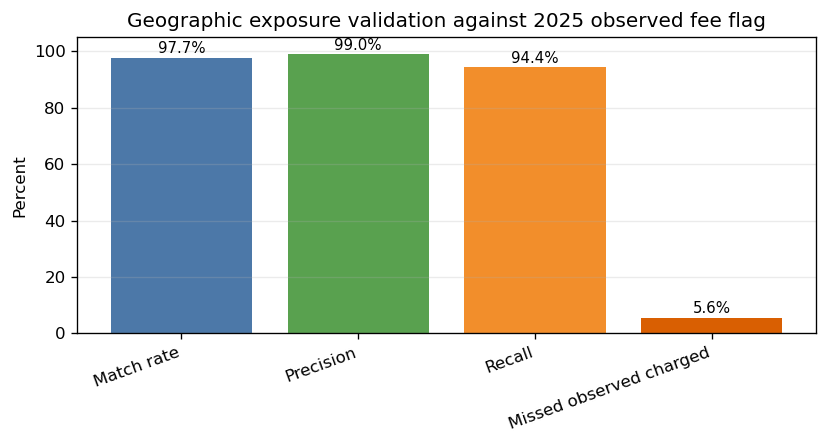

In [11]:
validation_plot = pd.DataFrame({
    "metric": ["Match rate", "Precision", "Recall", "Missed observed charged"],
    "percent": [
        validation_summary["match_rate_pct"].iloc[0],
        validation_summary["geography_precision_pct"].iloc[0],
        validation_summary["geography_recall_pct"].iloc[0],
        validation_summary["share_observed_charged_missed_by_geo_pct"].iloc[0],
    ],
})

if MATPLOTLIB_AVAILABLE:
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.bar(validation_plot["metric"], validation_plot["percent"], color=["#4C78A8", "#59A14F", "#F28E2B", "#D95F02"])
    ax.set_title("Geographic exposure validation against 2025 observed fee flag")
    ax.set_ylabel("Percent")
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.25)
    for index, row in validation_plot.iterrows():
        ax.text(index, row["percent"] + 1.5, f"{row['percent']:.1f}%", ha="center", fontsize=9)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
else:
    print("matplotlib_available is False; chart will render when the notebook runs in the project environment.")

In [12]:
model2_base = panel.dropna(subset=["charged_share_2024_geo", "log_n_trips", "post"]).copy()
unit_exposure = model2_base.drop_duplicates(["zone", "direction"])[["zone", "direction", "Borough", "charged_share_2024_geo"]].copy()
unit_exposure["exposure_quartile"] = pd.qcut(
    unit_exposure["charged_share_2024_geo"],
    4,
    labels=["Q1 low", "Q2", "Q3", "Q4 high"],
    duplicates="drop",
)
model2_base = model2_base.merge(unit_exposure[["zone", "direction", "exposure_quartile"]], on=["zone", "direction"], how="left")

exposure_distribution = unit_exposure["charged_share_2024_geo"].describe().to_frame("charged_share_2024_geo").T.reset_index(drop=True)
borough_exposure = unit_exposure.groupby("Borough", observed=True)["charged_share_2024_geo"].agg(["count", "mean", "median", "min", "max"]).reset_index().sort_values("mean", ascending=False)
quartile_pre_post = model2_base.groupby(["exposure_quartile", "post"], observed=True).agg(
    rows=("n_trips", "size"),
    units=("zone_direction", "nunique"),
    avg_log_n=("log_n_trips", "mean"),
    avg_n_trips=("n_trips", "mean"),
).reset_index()
quartile_change = model2_base.groupby(["exposure_quartile", "post"], observed=True)["log_n_trips"].mean().unstack()
quartile_change["post_minus_pre_log"] = quartile_change[1] - quartile_change[0]
quartile_change["pct_change_from_log_diff"] = (np.exp(quartile_change["post_minus_pre_log"]) - 1) * 100
quartile_change = quartile_change.reset_index()

print("Exposure distribution across zone-direction units:")
print_table(exposure_distribution, round_digits=3)
print("\nExposure by borough:")
print_table(borough_exposure, round_digits=3)
print("\nAverage log trips by exposure quartile and post:")
print_table(quartile_pre_post, round_digits=3)
print("\nQuartile-level pre/post log change, diagnostic only:")
print_table(quartile_change, round_digits=3)

Exposure distribution across zone-direction units:
 count  mean   std  min   25%   50%   75%  max
 525.0 0.222 0.337  0.0 0.031 0.056 0.204  1.0

Exposure by borough:
      Borough  count  mean  median   min   max
    Manhattan    135 0.678   1.000 0.028 1.000
          EWR      2 0.336   0.336 0.000 0.671
      Unknown      2 0.186   0.186 0.022 0.349
     Brooklyn    122 0.095   0.068 0.013 0.356
       Queens    138 0.059   0.041 0.008 0.412
        Bronx     86 0.039   0.037 0.000 0.093
Staten Island     40 0.027   0.024 0.003 0.055

Average log trips by exposure quartile and post:
exposure_quartile  post  rows  units  avg_log_n  avg_n_trips
           Q1 low     0   666    134     10.216    49343.390
           Q1 low     1   664    134     10.295    51311.270
               Q2     0   645    129     10.383    46457.847
               Q2     1   645    129     10.421    47916.377
               Q3     0   655    131     10.571    81740.986
               Q3     1   655    131     

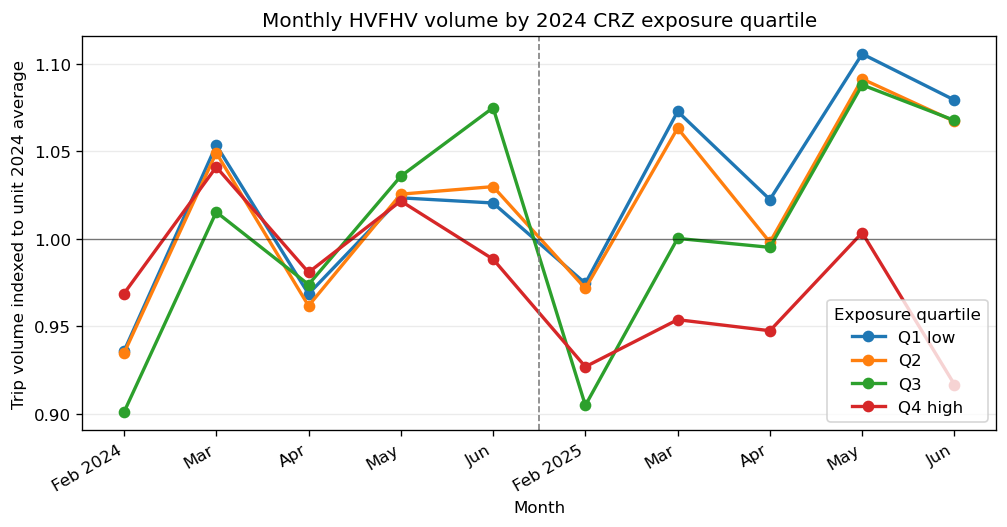

In [13]:
unit_baseline_2024 = model2_base[model2_base["year"].eq(2024)].groupby("zone_direction", observed=True)["n_trips"].mean().rename("baseline_2024_volume")
monthly_indexed = model2_base.merge(unit_baseline_2024, on="zone_direction", how="left")
monthly_indexed = monthly_indexed[monthly_indexed["baseline_2024_volume"] > 0].copy()
monthly_indexed["indexed_volume"] = monthly_indexed["n_trips"] / monthly_indexed["baseline_2024_volume"]
monthly_indexed["month_index"] = (monthly_indexed["year"] - 2024) * 5 + (monthly_indexed["month"] - 2)
monthly_indexed["month_label"] = monthly_indexed["year"].astype(str) + "-" + monthly_indexed["month"].astype(str).str.zfill(2)

monthly_lines = monthly_indexed.groupby(["exposure_quartile", "year", "month", "month_index", "month_label"], observed=True).agg(
    indexed_volume=("indexed_volume", "mean"),
).reset_index().sort_values(["exposure_quartile", "month_index"])

if MATPLOTLIB_AVAILABLE:
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    for quartile, group in monthly_lines.groupby("exposure_quartile", observed=True):
        group = group.sort_values("month_index")
        ax.plot(group["month_index"], group["indexed_volume"], marker="o", linewidth=2, label=str(quartile))
    ax.axvline(4.5, color="gray", linestyle="--", linewidth=1)
    ax.axhline(1.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title("Monthly HVFHV volume by 2024 CRZ exposure quartile")
    ax.set_xlabel("Month")
    ax.set_ylabel("Trip volume indexed to unit 2024 average")
    ax.set_xticks(range(10))
    ax.set_xticklabels(["Feb 2024", "Mar", "Apr", "May", "Jun", "Feb 2025", "Mar", "Apr", "May", "Jun"], rotation=30, ha="right")
    ax.legend(title="Exposure quartile")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    fig.savefig(RESULTS_FIGURES/'hvfhv_model2_exposure_trajectories.png', dpi=180, bbox_inches='tight')
else:
    print("matplotlib_available is False; chart will render when the notebook runs in the project environment.")

### Binary CRZ diagnostic

The continuous `charged_share_2024_geo` specification is primary. A binary CRZ/non-CRZ split is reported only as a contamination diagnostic, because many non-CRZ zone-sides still have trips that touch the CRZ.


In [14]:
model2_base['crz_int'] = model2_base['crz_zone'].astype(int)
unit_binary = model2_base.drop_duplicates(['zone', 'direction'])[['zone', 'direction', 'crz_zone', 'charged_share_2024_geo']]
non_crz_median = unit_binary.loc[~unit_binary['crz_zone'].astype(bool), 'charged_share_2024_geo'].median()
print(f"Median charged_share among non-CRZ 'control' zone-sides: {non_crz_median:.3f}")

binary_model2_results = pd.DataFrame([
    fit_model2_spec(model2_base, 'binary_simple', fe=False, exposure='crz_int'),
    fit_model2_spec(model2_base, 'binary_zone_direction_month_fe', fe=True, exposure='crz_int'),
])

print('\nBinary CRZ diagnostic coefficient on post:crz_int')
print_table(
    binary_model2_results,
    ['model', 'coef', 'std_error', 'ci_low', 'ci_high', 'pct_change', 'pct_ci_low', 'pct_ci_high', 'n', 'zone_direction_units', 'rank', 'se_type', 'engine'],
    round_digits=4,
)


Median charged_share among non-CRZ 'control' zone-sides: 0.044



Binary CRZ diagnostic coefficient on post:crz_int
                         model    coef  std_error  ci_low  ci_high  pct_change  pct_ci_low  pct_ci_high    n  zone_direction_units  rank      se_type      engine
                 binary_simple -0.1025     0.0129 -0.1278  -0.0772     -9.7408    -11.9958      -7.4279 5233                   525     4 cluster_zone statsmodels
binary_zone_direction_month_fe -0.0978     0.0069 -0.1114  -0.0842     -9.3180    -10.5440      -8.0752 5233                   525   531 cluster_zone statsmodels


**Chart finding.** The indexed monthly lines are a diagnostic visualization of exposure-group movement over the matched February to June windows. They make the post-period gap easier to inspect, but they do not prove parallel trends or clean assignment.

In [15]:
model2_results = pd.DataFrame([
    fit_model2_spec(model2_base, "simple", fe=False),
    fit_model2_spec(model2_base, "zone_direction_month_fe", fe=True),
])

print("Model 2 coefficient on post:charged_share_2024_geo")
print("Formula simple: log_n_trips ~ post * charged_share_2024_geo")
print("Formula FE style: log_n_trips ~ post + post:charged_share_2024_geo + C(zone_direction) + C(month)")
print_table(
    model2_results,
    ["model", "coef", "std_error", "ci_low", "ci_high", "pct_change", "pct_ci_low", "pct_ci_high", "n", "zone_direction_units", "rank", "se_type", "engine"],
    round_digits=4,
)

Model 2 coefficient on post:charged_share_2024_geo
Formula simple: log_n_trips ~ post * charged_share_2024_geo
Formula FE style: log_n_trips ~ post + post:charged_share_2024_geo + C(zone_direction) + C(month)
                  model    coef  std_error  ci_low  ci_high  pct_change  pct_ci_low  pct_ci_high    n  zone_direction_units  rank      se_type      engine
                 simple -0.1591     0.0355 -0.2287  -0.0895    -14.7092    -20.4450      -8.5600 5233                   525     4 cluster_zone statsmodels
zone_direction_month_fe -0.1130     0.0076 -0.1279  -0.0981    -10.6874    -12.0086      -9.3465 5233                   525   531 cluster_zone statsmodels


In [16]:
model2_low_volume_trim = model2_base[model2_base["n_trips"] >= 30].copy()
baseline_weights = (
    model2_base[model2_base["year"].eq(2024)]
    .groupby(["zone", "direction"], observed=True)["n_trips"]
    .mean()
    .rename("baseline_n_trips_2024")
    .reset_index()
)
model2_weighted = model2_base.merge(baseline_weights, on=["zone", "direction"], how="left")

robustness_results = pd.DataFrame([
    fit_model2_spec(model2_low_volume_trim, "simple_n_trips_ge_30", fe=False),
    fit_model2_spec(model2_low_volume_trim, "fe_n_trips_ge_30", fe=True),
    fit_model2_spec(model2_weighted, "simple_wls_baseline_2024", fe=False, weights_col="baseline_n_trips_2024"),
    fit_model2_spec(model2_weighted, "fe_wls_baseline_2024", fe=True, weights_col="baseline_n_trips_2024"),
])

robustness_qa = pd.DataFrame([
    {"check": "main_after_missing_exposure_drop", "rows": len(model2_base), "zone_direction_units": model2_base[["zone", "direction"]].drop_duplicates().shape[0]},
    {"check": "exclude_n_trips_lt_30", "rows": len(model2_low_volume_trim), "zone_direction_units": model2_low_volume_trim[["zone", "direction"]].drop_duplicates().shape[0]},
    {"check": "baseline_weight_available", "rows": int(model2_weighted["baseline_n_trips_2024"].notna().sum()), "zone_direction_units": model2_weighted.dropna(subset=["baseline_n_trips_2024"])[["zone", "direction"]].drop_duplicates().shape[0]},
])

print("Robustness sample QA:")
print_table(robustness_qa, round_digits=0)
print("\nRobustness estimates for post:charged_share_2024_geo:")
print_table(
    robustness_results,
    ["model", "coef", "std_error", "ci_low", "ci_high", "pct_change", "pct_ci_low", "pct_ci_high", "n", "zone_direction_units", "rank", "se_type", "engine"],
    round_digits=4,
)

Robustness sample QA:
                           check  rows  zone_direction_units
main_after_missing_exposure_drop  5233                   525
           exclude_n_trips_lt_30  5183                   519
       baseline_weight_available  5233                   525

Robustness estimates for post:charged_share_2024_geo:
                   model    coef  std_error  ci_low  ci_high  pct_change  pct_ci_low  pct_ci_high    n  zone_direction_units  rank      se_type      engine
    simple_n_trips_ge_30 -0.1190     0.0075 -0.1338  -0.1043    -11.2230    -12.5197      -9.9071 5183                   519     4 cluster_zone statsmodels
        fe_n_trips_ge_30 -0.1158     0.0070 -0.1295  -0.1021    -10.9358    -12.1484      -9.7064 5183                   519   525 cluster_zone statsmodels
simple_wls_baseline_2024 -0.0969     0.0064 -0.1095  -0.0843     -9.2331    -10.3704      -8.0814 5233                   525     4 cluster_zone statsmodels
    fe_wls_baseline_2024 -0.0969     0.0068 -0.1102  -0

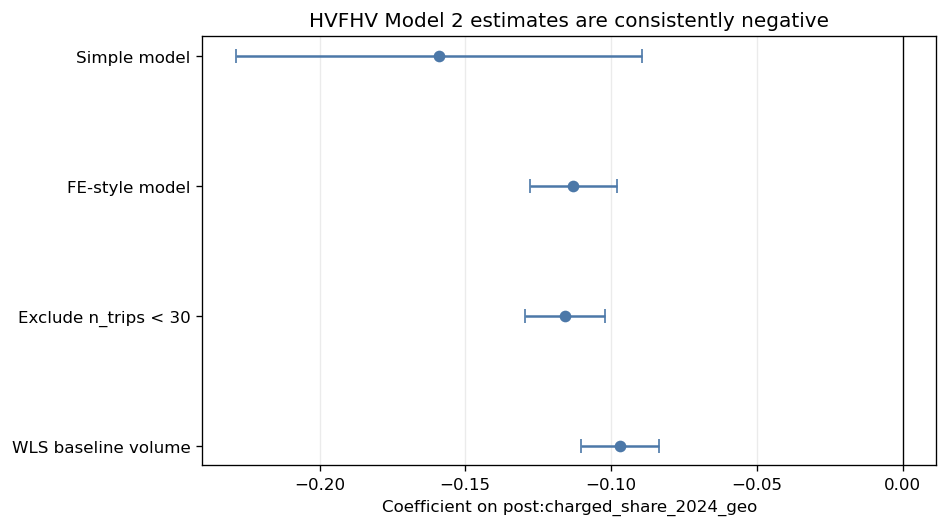

In [17]:
coef_plot = pd.concat([
    model2_results.assign(chart_label=model2_results["model"].map({
        "simple": "Simple model",
        "zone_direction_month_fe": "FE-style model",
    })),
    robustness_results[robustness_results["model"].isin(["fe_n_trips_ge_30", "fe_wls_baseline_2024"])].assign(
        chart_label=lambda frame: frame["model"].map({
            "fe_n_trips_ge_30": "Exclude n_trips < 30",
            "fe_wls_baseline_2024": "WLS baseline volume",
        })
    ),
], ignore_index=True)
coef_plot = coef_plot.dropna(subset=["chart_label"]).copy()
coef_plot["chart_label"] = pd.Categorical(
    coef_plot["chart_label"],
    categories=["Simple model", "FE-style model", "Exclude n_trips < 30", "WLS baseline volume"],
    ordered=True,
)
coef_plot = coef_plot.sort_values("chart_label")
coef_plot["err_low"] = coef_plot["coef"] - coef_plot["ci_low"]
coef_plot["err_high"] = coef_plot["ci_high"] - coef_plot["coef"]

if MATPLOTLIB_AVAILABLE:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    y_positions = np.arange(len(coef_plot))
    ax.errorbar(
        coef_plot["coef"],
        y_positions,
        xerr=[coef_plot["err_low"], coef_plot["err_high"]],
        fmt="o",
        color="#4C78A8",
        ecolor="#4C78A8",
        capsize=4,
    )
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(coef_plot["chart_label"].astype(str))
    ax.invert_yaxis()
    ax.set_title("HVFHV Model 2 estimates are consistently negative")
    ax.set_xlabel("Coefficient on post:charged_share_2024_geo")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    fig.savefig(RESULTS_FIGURES/'hvfhv_model2_specification_estimates.png', dpi=180, bbox_inches='tight')
else:
    print("matplotlib_available is False; chart will render when the notebook runs in the project environment.")

**Chart finding.** The simple, FE-style, low-volume-trim, and baseline-volume WLS estimates are all negative. The robustness chart supports a consistent exposure-gradient association estimated under assumptions, without making a causal claim.

## Model 2 diagnostic: no-June pretrend and placebo

These diagnostics exclude June to reduce exposure to June-specific event risks. The 2024-only pretrend check asks whether high- and low-exposure units were already moving differently before the 2025 policy window. The 2023→2024 placebo asks whether a similar exposure-gradient pattern appears in a comparison where no 2025 CBD fee existed.

These checks are diagnostic only. They do not prove or disprove parallel trends, and they do not turn Model 2 into causal proof.

In [18]:
pretrend_summary = pd.DataFrame([
    {
        "diagnostic": "2024 pretrend interaction",
        "coefficient": -0.012863,
        "std_error": 0.020331,
        "ci_lower": -0.052711,
        "ci_upper": 0.026984,
        "interpretation": "weak/no clear pretrend signal",
    }
])

placebo_fe = placebo_2023_2024_results[
    placebo_2023_2024_results["model_name"].eq("placebo_unit_fe")
].iloc[0]
model2_fe = model2_results[model2_results["model"].eq("zone_direction_month_fe")].iloc[0]

diagnostic_results = pd.concat(
    [
        pretrend_summary,
        pd.DataFrame([
            {
                "diagnostic": "2023→2024 placebo FE",
                "coefficient": placebo_fe["coefficient"],
                "std_error": placebo_fe["standard_error"],
                "ci_lower": placebo_fe["ci_lower"],
                "ci_upper": placebo_fe["ci_upper"],
                "interpretation": "weakens causal interpretation",
            },
            {
                "diagnostic": "2024→2025 Model 2 FE-style",
                "coefficient": model2_fe["coef"],
                "std_error": model2_fe["std_error"],
                "ci_lower": model2_fe["ci_low"],
                "ci_upper": model2_fe["ci_high"],
                "interpretation": "similar magnitude to placebo",
            },
        ]),
    ],
    ignore_index=True,
)

print_table(diagnostic_results, round_digits=6)

                   diagnostic  coefficient  std_error  ci_lower  ci_upper                interpretation
    2024 pretrend interaction    -0.012863   0.020331 -0.052711  0.026984 weak/no clear pretrend signal
      2023→2024 placebo FE    -0.101224   0.010633 -0.122064 -0.080383 weakens causal interpretation
2024→2025 Model 2 FE-style    -0.113028   0.007604 -0.127931 -0.098125  similar magnitude to placebo


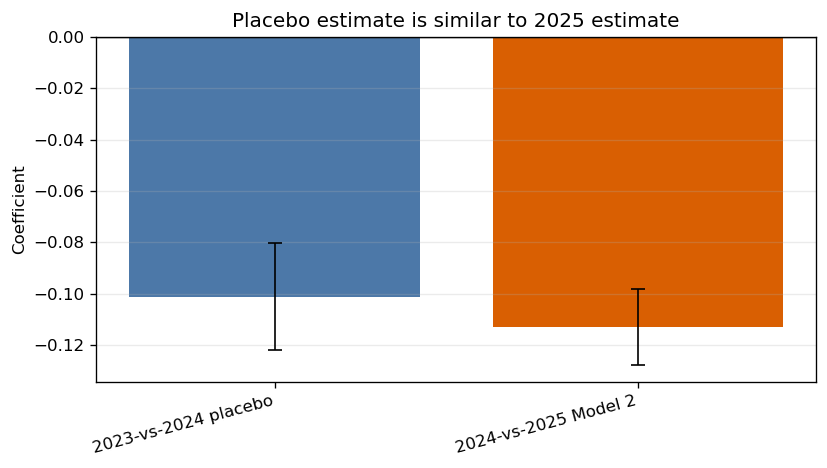

In [19]:
placebo_comparison = diagnostic_results[
    diagnostic_results["diagnostic"].isin([
        "2024→2025 Model 2 FE-style",
        "2023→2024 placebo FE",
    ])
].copy()
placebo_comparison["label"] = placebo_comparison["diagnostic"].map({
    "2024→2025 Model 2 FE-style": "2024→2025 Model 2",
    "2023→2024 placebo FE": "2023→2024 placebo",
})
placebo_comparison["err_low"] = placebo_comparison["coefficient"] - placebo_comparison["ci_lower"]
placebo_comparison["err_high"] = placebo_comparison["ci_upper"] - placebo_comparison["coefficient"]

if MATPLOTLIB_AVAILABLE:
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ["#4C78A8", "#D95F02"]
    positions = np.arange(len(placebo_comparison))
    ax.bar(positions, placebo_comparison["coefficient"], color=colors)
    ax.errorbar(
        positions,
        placebo_comparison["coefficient"],
        yerr=[placebo_comparison["err_low"], placebo_comparison["err_high"]],
        fmt="none",
        ecolor="black",
        capsize=4,
        linewidth=1,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(placebo_comparison["label"], rotation=15, ha="right")
    ax.set_ylabel("Coefficient")
    ax.set_title("Placebo estimate is similar to 2025 estimate")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    fig.savefig(RESULTS_FIGURES/'hvfhv_model2_placebo_comparison.png', dpi=180, bbox_inches='tight')
else:
    print("matplotlib_available is False; chart will render when the notebook runs in the project environment.")

**Diagnostic finding.** The no-June 2024 pretrend interaction is small and its interval crosses zero, so it does not show a clear pretrend signal. However, the no-June 2023→2024 placebo FE estimate is negative and similar in magnitude to the 2024→2025 Model 2 FE-style estimate. That weakens the causal interpretation of Model 2 and suggests that pre-existing spatial demand trends in high-exposure HVFHV zones may be part of the observed 2024→2025 exposure-gradient association.

**Model 2 finding and caveats.** After dropping rows with missing `charged_share_2024_geo`, the main panel has 5,233 rows and 525 zone-direction units. The simple model estimates a `post:charged_share_2024_geo` coefficient of -0.1591 with cluster-zone SE 0.0355 and 95 percent CI [-0.2287, -0.0895]. The feasible FE-style model estimates -0.1130 with cluster-zone SE 0.0076 and 95 percent CI [-0.1279, -0.0981], which is about -10.7 percent for a zero-to-full exposure contrast under the log specification.

Robustness checks point in the same direction. Excluding rows with `n_trips < 30` gives an FE-style coefficient of about -0.1158. WLS weighted by 2024 baseline trip volume is feasible and gives an FE-style coefficient of about -0.0969. The binary CRZ split is reported as a contamination diagnostic; the continuous exposure remains the primary treatment definition because non-CRZ zone-sides are still partly exposed.

The no-June placebo warning materially changes the interpretation. Model 2 still shows a negative 2024→2025 exposure-gradient estimate, but the 2023→2024 placebo is also negative and similar in magnitude. Model 2 should therefore be presented as a suggestive association, not clean causal evidence. This pattern may reflect pre-existing spatial demand trends in high-exposure HVFHV zones.

Required caveats: the exposure-gradient DiD interpretation depends on parallel trends by exposure, which is not proven here. Spillovers are plausible because trip behavior can shift across zones and directions. Geography-based exposure can miss some through-trips or routing details. The validation diagnostic shows that the geo-only rule missed 5.6 percent of observed charged trips in 2025. The validation has high match, precision, and recall, but it is diagnostic evidence, not proof of clean treatment assignment.

## Result exports


In [20]:
corr_export = corr_summary.rename(columns={'corr':'correlation'})[
    ['metric','method','n','correlation','ci_low','ci_high']]
corr_export.to_csv(RESULTS_TABLES/'hvfhv_model1_correlations.csv', index=False)

quartile_export = quartile_all.rename(columns={
    'DS_z_quartile':'burden_quartile', 'n_pairs':'n_zone_directions',
    'avg_DS_z_pct':'mean_DS_z_pct', 'avg_volume_change_pct':'mean_volume_change_pct',
})[['burden_quartile','n_zone_directions','mean_DS_z_pct','mean_volume_change_pct','median_volume_change_pct']]
quartile_export.to_csv(RESULTS_TABLES/'hvfhv_model1_quartiles.csv', index=False)

spec_export = model1_spec_results.rename(columns={'coef':'coefficient'})[
    ['spec','coefficient','std_error','ci_low','ci_high','n']]
spec_export.to_csv(RESULTS_TABLES/'hvfhv_model1_specs.csv', index=False)

model2_specifications = pd.concat([
    model2_results.assign(result_group='primary'),
    binary_model2_results.assign(result_group='binary_crz'),
    robustness_results.assign(result_group='robustness'),
], ignore_index=True)
model2_specifications.to_csv(RESULTS_TABLES/'hvfhv_model2_specifications.csv', index=False)

def _summary_row(window, spec, row):
    return {'window':window, 'spec':spec, 'estimate_pct':row['pct_change'],
            'ci_low':row['pct_ci_low'], 'ci_high':row['pct_ci_high']}

summary_rows = [
    _summary_row('2024→2025','higher-exposure FE-style', model2_results[model2_results.model.eq('zone_direction_month_fe')].iloc[0]),
    _summary_row('2024→2025','higher-exposure, volume-weight', robustness_results[robustness_results.model.eq('fe_wls_baseline_2024')].iloc[0]),
    _summary_row('2024→2025','exclude n_trips < 30', robustness_results[robustness_results.model.eq('fe_n_trips_ge_30')].iloc[0]),
    _summary_row('2024→2025','binary CRZ FE-style', binary_model2_results[binary_model2_results.model.eq('binary_zone_direction_month_fe')].iloc[0]),
]
_placebo = diagnostic_results[diagnostic_results.diagnostic.eq('2023→2024 placebo FE')].iloc[0]
summary_rows.append({'window':'2023→2024 placebo','spec':'higher-exposure FE-style',
                     'estimate_pct':(np.exp(_placebo.coefficient)-1)*100,
                     'ci_low':(np.exp(_placebo.ci_lower)-1)*100,
                     'ci_high':(np.exp(_placebo.ci_upper)-1)*100})
pd.DataFrame(summary_rows).to_csv(RESULTS_TABLES/'hvfhv_model2_estimates.csv', index=False)

diagnostic_results.to_csv(RESULTS_TABLES/'hvfhv_model2_diagnostics.csv', index=False)
exposure_validation.to_csv(RESULTS_TABLES/'hvfhv_model2_exposure_validation.csv', index=False)
print('Exported HVFHV Model 1 and Model 2 result tables and figures.')


Exported HVFHV Model 1 and Model 2 result tables and figures.


## Final Summary

- Model 1: Higher HVFHV `DS_z` is strongly associated with lower 2025 vs 2024 volume change. The descriptive association is strong in this processed feature table, with Pearson -0.610 and rank-based Spearman -0.643. This is a descriptive burden-volume association, not causal attribution.
- Model 2: Using only the 2024 geography-based exposure, the FE-style exposure-gradient estimate is negative for 2024→2025. However, the no-June 2023→2024 placebo FE estimate is also negative and similar in magnitude. This placebo warning weakens causal interpretation and suggests pre-existing spatial demand trends may be part of the observed exposure-gradient pattern.
- Exposure validation: The 2025 observed charged-flag diagnostic has high match, precision, and recall, with 5.6 percent of observed charged trips missed by the geo-only rule. This supports using the exposure cautiously as a diagnostic-quality assignment proxy, not as proof of clean assignment.

Overall, HVFHV Model 1 is a descriptive burden-volume association readout. Model 2 provides a negative exposure-gradient association estimated under assumptions, but the placebo diagnostic means it should not be framed as clean causal evidence.